In [1]:

import numpy as np
from keras.models import Sequential
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

In [2]:

(x_train,y_train),(x_test,y_test)=cifar10.load_data()

In [3]:

y_train_cat=to_categorical(y_train)
y_test_cat=to_categorical(y_test)

In [4]:

model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(1024,activation='relu'))
model.add(Dense(512,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [5]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [6]:
cb=ModelCheckpoint('best_model.h5',monitor='val_loss',mode='min',save_best_only=True)

Epoch 1/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2642 - loss: 2.6756

625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.3427 - loss: 1.9735 - val_accuracy: 0.4416 - val_loss: 1.5586
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4802 - loss: 1.4587

625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.4961 - loss: 1.4223 - val_accuracy: 0.5224 - val_loss: 1.3565
Epoch 3/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5600 - loss: 1.2503

625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.5613 - loss: 1.2392 - val_accuracy: 0.5390 - val_loss: 1.3199
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6118 - loss: 1.1095

625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6128 - loss: 1.1012 - val_accuracy: 0.5830 - val_loss: 1.2017
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6591 - loss: 0.9820

625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6587 - loss: 0.9778 - val_accuracy: 0.5973 - val_loss: 1.1698
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7012 - loss: 0.8601 - val_accuracy: 0.5865 - val_loss: 1.2177
Epoch 7/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7466 - loss: 0.7392

625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7424 - loss: 0.7457 - val_accuracy: 0.6290 - val_loss: 1.1225
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7864 - loss: 0.6243 - val_accuracy: 0.6256 - val_loss: 1.1680
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8285 - loss: 0.5058 - val_accuracy: 0.6198 - val_loss: 1.2165
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8668 - loss: 0.3965 - val_accuracy: 0.6250 - val_loss: 1.2858
Epoch 11/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9015 - loss: 0.3044 - val_accuracy: 0.6280 - val_loss: 1.3282
Epoch 12/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9277 - loss: 0.2277 - val_accuracy: 0.6295 - val_loss: 1.4662
Epoch 13/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9524 - loss: 0.1605 - val_accuracy: 0.6272 - val_loss: 1.5672
Epoch 14/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9595 - loss: 0.1329 - val_ac

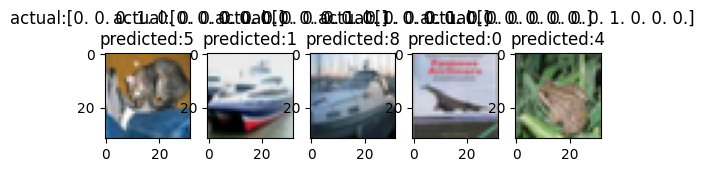

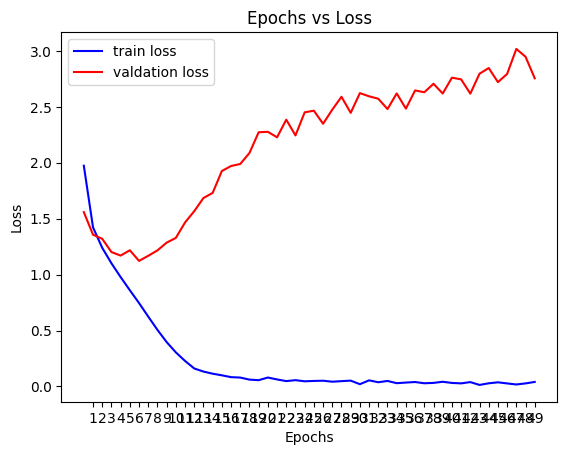

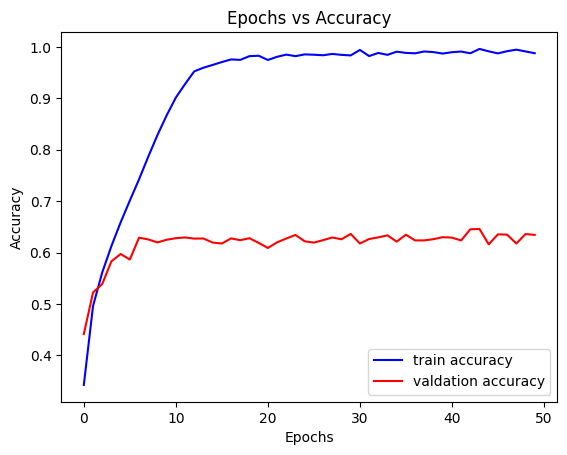

In [7]:
result=model.fit(x_train,y_train_cat,epochs=50,batch_size=64,validation_split=0.2,callbacks=[cb])
loss,test_accuracy=model.evaluate(x_test,y_test_cat)

predictions=model.predict(x_test)
predict_label=np.argmax(predictions,axis=1)
print(f"predicted label:{predict_label[1]}")

#Print the predicted image
for i in range(5):
    #print(f"actual:{y_test[i]}\npredicted:{predict_label[i]}")
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i])
    plt.title(f"actual:{y_test_cat[i]}\npredicted:{predict_label[i]}")
plt.show()
plt.plot(result.history['loss'],label='train loss',color='blue')
plt.plot(result.history['val_loss'],label='valdation loss',color='red')
plt.xticks(np.arange(1,50))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Epochs vs Loss")
plt.legend()
plt.show()

plt.plot(result.history['accuracy'],label='train accuracy',color='blue')
plt.plot(result.history['val_accuracy'],label='valdation accuracy',color='red')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Epochs vs Accuracy")
plt.legend()
plt.show()